In [1]:
#Practice
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn

In [9]:
import pandas as pd
col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin',
             'bmi', 'pedigree', 'age', 'label']
data = pd.read_csv('/content/diabetes.csv',
                   skiprows=1,
                   names=col_names)
print(data.shape)
data.head()

(100, 9)


,pregnant,glucose,bp,skin,insulin,bmi,pedigree,age,label
0,6,90,67,35,0,37.2,1.521,66,0
1,3,73,61,19,251,30.0,1.221,56,1
2,12,143,68,21,83,46.4,1.077,43,1
3,10,104,79,8,110,29.8,0.924,21,0
4,7,80,85,17,49,28.9,2.329,60,1


In [5]:
data.isnull().sum()

,0
pregnant,0
glucose,0
bp,0
skin,0
insulin,0
bmi,0
pedigree,0
age,0
label,0


In [10]:
feature_cols = ['pregnant', 'insulin', 'bmi',
                'age', 'glucose', 'bp', 'pedigree']
x = data[feature_cols]
y = data.label

In [11]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=5
)
display(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

(80, 7)

(80,)

(20, 7)

(20,)

In [12]:
model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [13]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix : ', conf_mat)
Accuracy_score = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score : ', Accuracy_score)
print('Accuracy in Percentage : ', int(Accuracy_score * 100), '%')

Confusion Matrix :  [[ 3  4]
 [ 2 11]]
Accuracy Score :  0.7
Accuracy in Percentage :  70 %


<Axes: xlabel='Predicted', ylabel='Actual'>

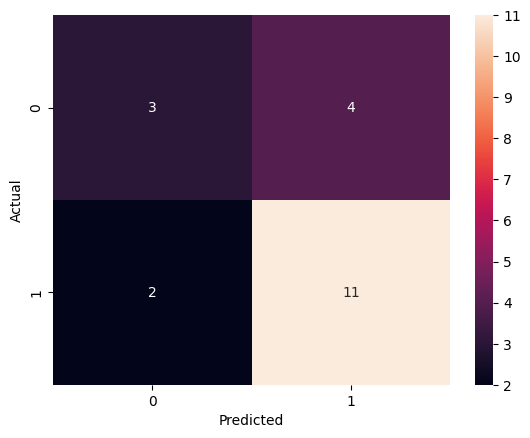

In [14]:
conf_mat = pd.crosstab(
    y_test,
    y_pred,
    rownames=['Actual'],
    colnames=['Predicted']
)
sn.heatmap(conf_mat, annot=True)

In [15]:
#Exercise
#1
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [16]:
url = "https://stats.idre.ucla.edu/stat/data/binary.csv"
data = pd.read_csv(url)
data.head()

,admit,gre,gpa,rank
0,0,380,3.61,3
1,1,660,3.67,3
2,1,800,4.00,1
3,1,640,3.19,4
4,0,520,2.93,4


In [17]:
print("Shape of dataset:", data.shape)
print("\nColumn names:")
print(data.columns)
print("\nData types:")
print(data.dtypes)
print("\nFirst 5 rows:")
print(data.head())

Shape of dataset: (400, 4)

Column names:
Index(['admit', 'gre', 'gpa', 'rank'], dtype='object')

Data types:
admit      int64
gre        int64
gpa      float64
rank       int64
dtype: object

First 5 rows:
   admit  gre   gpa  rank
0      0  380  3.61     3
1      1  660  3.67     3
2      1  800  4.00     1
3      1  640  3.19     4
4      0  520  2.93     4


In [18]:
print(data.isnull().sum())

admit    0
gre      0
gpa      0
rank     0
dtype: int64


In [19]:
data.describe()

,admit,gre,gpa,rank
count,400.000000,400.000000,400.000000,400.00000
mean,0.317500,587.700000,3.389900,2.48500
std,0.466087,115.516536,0.380567,0.94446
min,0.000000,220.000000,2.260000,1.00000
25%,0.000000,520.000000,3.130000,2.00000
50%,0.000000,580.000000,3.395000,2.00000
75%,1.000000,660.000000,3.670000,3.00000
max,1.000000,800.000000,4.000000,4.00000


In [20]:
print(data["admit"].value_counts())
print("\nPercentage:")
print(data["admit"].value_counts(normalize=True) * 100)

admit
0    273
1    127
Name: count, dtype: int64

Percentage:
admit
0    68.25
1    31.75
Name: proportion, dtype: float64


In [21]:
data["rank"] = data["rank"].astype("category")
print(data.dtypes)

admit       int64
gre         int64
gpa       float64
rank     category
dtype: object


In [22]:
model = smf.glm(
    formula="admit ~ gre + gpa + C(rank)",
    data=data,
    family=sm.families.Binomial()
)
result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  admit   No. Observations:                  400
Model:                            GLM   Df Residuals:                      394
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -229.26
Date:                Wed, 19 Aug 2026   Deviance:                       458.52
Time:                        03:25:43   Pearson chi2:                     397.
No. Iterations:                     4   Pseudo R-squ. (CS):            0.09846
Covariance Type:            nonrobust                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -3.9900      1.140     -3.500   

In [23]:
print("Coefficients:")
print(result.params)

Coefficients:
Intercept      -3.989979
C(rank)[T.2]   -0.675443
C(rank)[T.3]   -1.340204
C(rank)[T.4]   -1.551464
gre             0.002264
gpa             0.804038
dtype: float64


In [24]:
odds_ratios = np.exp(result.params)
print("Odds Ratios:")
print(odds_ratios)

Odds Ratios:
Intercept       0.018500
C(rank)[T.2]    0.508931
C(rank)[T.3]    0.261792
C(rank)[T.4]    0.211938
gre             1.002267
gpa             2.234545
dtype: float64


In [25]:
confidence_intervals = result.conf_int()
confidence_intervals.columns = ["Lower", "Upper"]
print(confidence_intervals)

                 Lower     Upper
Intercept    -6.224242 -1.755716
C(rank)[T.2] -1.295751 -0.055135
C(rank)[T.3] -2.016992 -0.663416
C(rank)[T.4] -2.370399 -0.732529
gre           0.000120  0.004409
gpa           0.153684  1.454391


In [26]:
results = pd.DataFrame({
    "Coefficient": result.params,
    "Odds Ratio": np.exp(result.params),
    "P-value": result.pvalues
})
print(results)

              Coefficient  Odds Ratio   P-value
Intercept       -3.989979    0.018500  0.000465
C(rank)[T.2]    -0.675443    0.508931  0.032829
C(rank)[T.3]    -1.340204    0.261792  0.000104
C(rank)[T.4]    -1.551464    0.211938  0.000205
gre              0.002264    1.002267  0.038465
gpa              0.804038    2.234545  0.015388


In [27]:
alpha = 0.05
for variable, p_value in result.pvalues.items():
    if p_value < alpha:
        print(variable, "-> Significant")
    else:
        print(variable, "-> Not Significant")

Intercept -> Significant
C(rank)[T.2] -> Significant
C(rank)[T.3] -> Significant
C(rank)[T.4] -> Significant
gre -> Significant
gpa -> Significant


In [28]:
new_student = pd.DataFrame({
    "gre": [650],
    "gpa": [3.7],
    "rank": pd.Categorical([2], categories=data["rank"].cat.categories)
})
probability = result.predict(new_student)
print("Probability of admission:", probability.iloc[0])

Probability of admission: 0.4455650319931812


In [29]:
#2
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [30]:
data = pd.DataFrame({
    "Age": [
        22, 25, 18, 45, 12, 43, 23, 33,
        55, 31, 40, 52, 28, 36, 47, 60,
        19, 29, 34, 41, 50, 27, 38, 48,
        56, 24, 32, 44, 53, 21, 35, 46,
        58, 26, 39, 49
    ],

    "Gender": [
        "female", "female", "male", "male",
        "female", "male", "male", "male",
        "female", "female", "male", "female",
        "female", "male", "female", "male",
        "female", "male", "female", "male",
        "male", "female", "male", "female",
        "male", "female", "male", "female",
        "male", "female", "male", "female",
        "male", "female", "male", "female"
    ],

    "Smoker": [
        "Non-smoker", "Smoker", "Smoker", "Non-smoker",
        "Smoker", "Smoker", "Smoker", "Smoker",
        "Smoker", "Non-smoker", "Smoker", "Non-smoker",
        "Non-smoker", "Smoker", "Smoker", "Non-smoker",
        "Non-smoker", "Smoker", "Non-smoker", "Smoker",
        "Smoker", "Non-smoker", "Smoker", "Non-smoker",
        "Smoker", "Non-smoker", "Smoker", "Non-smoker",
        "Smoker", "Non-smoker", "Smoker", "Non-smoker",
        "Smoker", "Non-smoker", "Smoker", "Smoker"
    ],

    "Disease": [
        1, 1, 0, 0,
        0, 1, 0, 1,
        1, 0, 1, 0,
        0, 1, 1, 0,
        0, 0, 1, 1,
        1, 0, 1, 0,
        1, 0, 0, 1,
        1, 0, 1, 0,
        1, 0, 1, 1
    ]
})

data.head()

,Age,Gender,Smoker,Disease
0,22,female,Non-smoker,1
1,25,female,Smoker,1
2,18,male,Smoker,0
3,45,male,Non-smoker,0
4,12,female,Smoker,0


In [31]:
print("Shape of dataset:", data.shape)
print("\nColumn names:")
print(data.columns)
print("\nData types:")
print(data.dtypes)
print("\nFirst 10 rows:")
print(data.head(10))

Shape of dataset: (36, 4)

Column names:
Index(['Age', 'Gender', 'Smoker', 'Disease'], dtype='object')

Data types:
Age         int64
Gender     object
Smoker     object
Disease     int64
dtype: object

First 10 rows:
   Age  Gender      Smoker  Disease
0   22  female  Non-smoker        1
1   25  female      Smoker        1
2   18    male      Smoker        0
3   45    male  Non-smoker        0
4   12  female      Smoker        0
5   43    male      Smoker        1
6   23    male      Smoker        0
7   33    male      Smoker        1
8   55  female      Smoker        1
9   31  female  Non-smoker        0


In [32]:
print(data.isnull().sum())

Age        0
Gender     0
Smoker     0
Disease    0
dtype: int64


In [33]:
data.describe()

,Age,Disease
count,36.000000,36.000000
mean,37.194444,0.527778
std,12.745463,0.506309
min,12.000000,0.000000
25%,26.750000,0.000000
50%,37.000000,1.000000
75%,47.250000,1.000000
max,60.000000,1.000000


In [34]:
print(data["Disease"].value_counts())
print("\nPercentage:")
print(data["Disease"].value_counts(normalize=True) * 100)

Disease
1    19
0    17
Name: count, dtype: int64

Percentage:
Disease
1    52.777778
0    47.222222
Name: proportion, dtype: float64


In [35]:
data["Gender"] = data["Gender"].astype("category")
data["Smoker"] = data["Smoker"].astype("category")
print(data.dtypes)

Age           int64
Gender     category
Smoker     category
Disease       int64
dtype: object


In [36]:
model = smf.glm(
    formula="Disease ~ Age + C(Gender) + C(Smoker)",
    data=data,
    family=sm.families.Binomial()
)
result = model.fit()
print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                Disease   No. Observations:                   36
Model:                            GLM   Df Residuals:                       32
Model Family:                Binomial   Df Model:                            3
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14.929
Date:                Wed, 19 Aug 2026   Deviance:                       29.857
Time:                        04:00:26   Pearson chi2:                     39.7
No. Iterations:                     6   Pseudo R-squ. (CS):             0.4253
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -5.5446    

In [37]:
print("Coefficients:")
print(result.params)

Coefficients:
Intercept             -5.544614
C(Gender)[T.male]     -2.106329
C(Smoker)[T.Smoker]    4.445306
Age                    0.114707
dtype: float64


In [38]:
odds_ratios = np.exp(result.params)
print("Odds Ratios:")
print(odds_ratios)

Odds Ratios:
Intercept               0.003908
C(Gender)[T.male]       0.121684
C(Smoker)[T.Smoker]    85.225925
Age                     1.121545
dtype: float64


In [39]:
confidence_intervals = result.conf_int()
confidence_intervals.columns = ["Lower", "Upper"]
print(confidence_intervals)

                        Lower     Upper
Intercept           -9.670429 -1.418799
C(Gender)[T.male]   -5.101180  0.888521
C(Smoker)[T.Smoker]  1.144594  7.746017
Age                  0.017906  0.211508


In [40]:
results = pd.DataFrame({
    "Coefficient": result.params,
    "Odds Ratio": np.exp(result.params),
    "P-value": result.pvalues
})
print(results)

                     Coefficient  Odds Ratio   P-value
Intercept              -5.544614    0.003908  0.008439
C(Gender)[T.male]      -2.106329    0.121684  0.168056
C(Smoker)[T.Smoker]     4.445306   85.225925  0.008300
Age                     0.114707    1.121545  0.020206


In [41]:
alpha = 0.05
for variable, p_value in result.pvalues.items():
    if p_value < alpha:
        print(variable, "-> Significant")
    else:
        print(variable, "-> Not Significant")

Intercept -> Significant
C(Gender)[T.male] -> Not Significant
C(Smoker)[T.Smoker] -> Significant
Age -> Significant


In [42]:
new_person = pd.DataFrame({
    "Age": [55],
    "Gender": pd.Categorical(
        ["female"],
        categories=data["Gender"].cat.categories
    ),
    "Smoker": pd.Categorical(
        ["Smoker"],
        categories=data["Smoker"].cat.categories
    )
})
probability = result.predict(new_person)
print("Probability of disease:", probability.iloc[0])
print("Probability (%):", probability.iloc[0] * 100)

Probability of disease: 0.9945656993907036
Probability (%): 99.45656993907036


In [43]:
if probability.iloc[0] >= 0.5:
    print("Prediction: Diseased (1)")
else:
    print("Prediction: Not Diseased (0)")

Prediction: Diseased (1)


In [44]:
from sklearn.metrics import confusion_matrix, accuracy_score

predicted_probability = result.predict(data)

predicted_class = (predicted_probability >= 0.5).astype(int)

cm = confusion_matrix(data["Disease"], predicted_class)

print("Confusion Matrix:")
print(cm)

accuracy = accuracy_score(data["Disease"], predicted_class)

print("\nAccuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Confusion Matrix:
[[13  4]
 [ 3 16]]

Accuracy: 0.8055555555555556
Accuracy (%): 80.55555555555556


In [45]:
#3
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [46]:
data = pd.DataFrame({
    "Purchase": [
        "Buy now", "Buy now", "Buy now", "Buy now", "Buy now",
        "Buy now", "Buy now", "Buy now", "Buy now", "Buy now",

        "Buy later", "Buy later", "Buy later", "Buy later", "Buy later",
        "Buy later", "Buy later", "Buy later", "Buy later", "Buy later",

        "Don't buy", "Don't buy", "Don't buy", "Don't buy", "Don't buy",
        "Don't buy", "Don't buy", "Don't buy", "Don't buy", "Don't buy"
    ],

    "Gender": [
        "female", "female", "male", "male", "female",
        "male", "female", "male", "female", "male",

        "female", "female", "male", "male", "female",
        "male", "female", "male", "female", "male",

        "female", "female", "male", "male", "female",
        "male", "female", "male", "female", "male"
    ],

    "Age": [
        22, 25, 18, 30, 24,
        28, 21, 26, 23, 29,

        27, 27, 48, 35, 31,
        42, 38, 45, 33, 40,

        33, 43, 52, 46, 55,
        50, 41, 58, 47, 60
    ],

    "Time": [
        40, 78, 65, 70, 55,
        82, 45, 75, 60, 88,

        28, 15, 110, 35, 25,
        95, 42, 20, 30, 85,

        65, 34, 20, 18, 25,
        30, 15, 22, 28, 12
    ]
})

data.head()

,Purchase,Gender,Age,Time
0,Buy now,female,22,40
1,Buy now,female,25,78
2,Buy now,male,18,65
3,Buy now,male,30,70
4,Buy now,female,24,55


In [47]:
print("Shape of dataset:", data.shape)
print("\nColumn names:")
print(data.columns)
print("\nData types:")
print(data.dtypes)
print("\nFirst 10 rows:")
print(data.head(10))

Shape of dataset: (30, 4)

Column names:
Index(['Purchase', 'Gender', 'Age', 'Time'], dtype='object')

Data types:
Purchase    object
Gender      object
Age          int64
Time         int64
dtype: object

First 10 rows:
  Purchase  Gender  Age  Time
0  Buy now  female   22    40
1  Buy now  female   25    78
2  Buy now    male   18    65
3  Buy now    male   30    70
4  Buy now  female   24    55
5  Buy now    male   28    82
6  Buy now  female   21    45
7  Buy now    male   26    75
8  Buy now  female   23    60
9  Buy now    male   29    88


In [48]:
print(data.isnull().sum())

Purchase    0
Gender      0
Age         0
Time        0
dtype: int64


In [49]:
data.describe()

,Age,Time
count,30.000000,30.000000
mean,36.566667,47.066667
std,11.851621,27.937039
min,18.000000,12.000000
25%,27.000000,25.000000
50%,34.000000,37.500000
75%,45.750000,68.750000
max,60.000000,110.000000


In [50]:
print(data["Purchase"].value_counts())
print("\nPercentage:")
print(data["Purchase"].value_counts(normalize=True) * 100)

Purchase
Buy now      10
Buy later    10
Don't buy    10
Name: count, dtype: int64

Percentage:
Purchase
Buy now      33.333333
Buy later    33.333333
Don't buy    33.333333
Name: proportion, dtype: float64


In [51]:
gender_encoder = LabelEncoder()
purchase_encoder = LabelEncoder()
data["Gender_encoded"] = gender_encoder.fit_transform(data["Gender"])
data["Purchase_encoded"] = purchase_encoder.fit_transform(data["Purchase"])
print(data.head())

  Purchase  Gender  Age  Time  Gender_encoded  Purchase_encoded
0  Buy now  female   22    40               0                 1
1  Buy now  female   25    78               0                 1
2  Buy now    male   18    65               1                 1
3  Buy now    male   30    70               1                 1
4  Buy now  female   24    55               0                 1


In [52]:
print("Gender encoding:")
for i, value in enumerate(gender_encoder.classes_):
    print(value, "=", i)

print("\nPurchase encoding:")
for i, value in enumerate(purchase_encoder.classes_):
    print(value, "=", i)

Gender encoding:
female = 0
male = 1

Purchase encoding:
Buy later = 0
Buy now = 1
Don't buy = 2


In [53]:
X = data[["Gender_encoded", "Age", "Time"]]

y = data["Purchase_encoded"]

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   Gender_encoded  Age  Time
0               0   22    40
1               0   25    78
2               1   18    65
3               1   30    70
4               0   24    55

y:
0    1
1    1
2    1
3    1
4    1
Name: Purchase_encoded, dtype: int64


In [54]:
model = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000
)
model.fit(X, y)
print("Model trained successfully.")

Model trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [55]:
print("Coefficients:")
coefficients = pd.DataFrame(
    model.coef_,
    columns=["Gender", "Age", "Time"]
)
coefficients.index = purchase_encoder.classes_
print(coefficients)

Coefficients:
             Gender       Age      Time
Buy later  0.550876  0.259728 -0.066423
Buy now    0.111428 -0.769581  0.162659
Don't buy -0.662305  0.509852 -0.096236


In [56]:
probabilities = model.predict_proba(X)
probability_table = pd.DataFrame(
    probabilities,
    columns=purchase_encoder.classes_
)
print(probability_table.head(10))

   Buy later   Buy now     Don't buy
0   0.022683  0.977038  2.790018e-04
1   0.000084  0.999915  7.079487e-07
2   0.000002  0.999998  1.219373e-09
3   0.123140  0.875498  1.361498e-03
4   0.005820  0.994104  7.548712e-05
5   0.001147  0.998847  5.379155e-06
6   0.002631  0.997347  2.171229e-05
7   0.000728  0.999269  2.550677e-06
8   0.000665  0.999329  5.785132e-06
9   0.000813  0.999183  4.091555e-06


In [57]:
predicted = model.predict(X)
predicted_labels = purchase_encoder.inverse_transform(predicted)
data["Predicted_Purchase"] = predicted_labels
print(data[[
    "Purchase",
    "Gender",
    "Age",
    "Time",
    "Predicted_Purchase"
]].head(10))

  Purchase  Gender  Age  Time Predicted_Purchase
0  Buy now  female   22    40            Buy now
1  Buy now  female   25    78            Buy now
2  Buy now    male   18    65            Buy now
3  Buy now    male   30    70            Buy now
4  Buy now  female   24    55            Buy now
5  Buy now    male   28    82            Buy now
6  Buy now  female   21    45            Buy now
7  Buy now    male   26    75            Buy now
8  Buy now  female   23    60            Buy now
9  Buy now    male   29    88            Buy now


In [58]:
accuracy = accuracy_score(y, predicted)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.9333333333333333
Accuracy (%): 93.33333333333333


In [59]:
cm = confusion_matrix(y, predicted)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 9  0  1]
 [ 0 10  0]
 [ 1  0  9]]


In [60]:
print(classification_report(
    y,
    predicted,
    target_names=purchase_encoder.classes_
))

              precision    recall  f1-score   support

   Buy later       0.90      0.90      0.90        10
     Buy now       1.00      1.00      1.00        10
   Don't buy       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [61]:
new_customer = pd.DataFrame({
    "Gender_encoded": [
        gender_encoder.transform(["female"])[0]
    ],
    "Age": [27],
    "Time": [80]
})
prediction = model.predict(new_customer)
prediction_label = purchase_encoder.inverse_transform(prediction)
print("Predicted purchase:", prediction_label[0])

Predicted purchase: Buy now


In [62]:
new_probability = model.predict_proba(new_customer)
probability_result = pd.DataFrame(
    new_probability,
    columns=purchase_encoder.classes_
)
print("Purchase probabilities:")
print(probability_result)

Purchase probabilities:
   Buy later   Buy now  Don't buy
0   0.000418  0.999577   0.000005


In [63]:
most_likely = probability_result.idxmax(axis=1)[0]
highest_probability = probability_result.max(axis=1)[0]
print("Most likely purchase:", most_likely)
print("Probability:", highest_probability)
print("Probability (%):", highest_probability * 100)

Most likely purchase: Buy now
Probability: 0.9995765784342844
Probability (%): 99.95765784342844
